In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn import metrics

import seaborn as sn

In [ ]:
#generation of random quadratic dataset
np.random.seed(42)

# Generate random x values
x = np.random.uniform(-3, 3, 200)

# Generate random y values
y = np.random.uniform(-1, 9, 200)

# Classify points based on quadratic curve y = x²
# 0 = Below curve
# 1 = Above curve
target = (y > x**2).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'X': x,
    'Y': y,
    'Class': target
})

print(df.head(10))

          X         Y  Class
0 -0.752759  5.420316      1
1  2.704286 -0.158600      0
2  1.391964  0.616287      0
3  0.591951  7.985542      1
4 -2.063888  5.064291      1
5 -2.064033 -0.908029      0
6 -2.651498  0.014715      0
7  2.197057  5.635018      1
8  0.606690 -0.949384      0
9  1.248435  0.608081      0


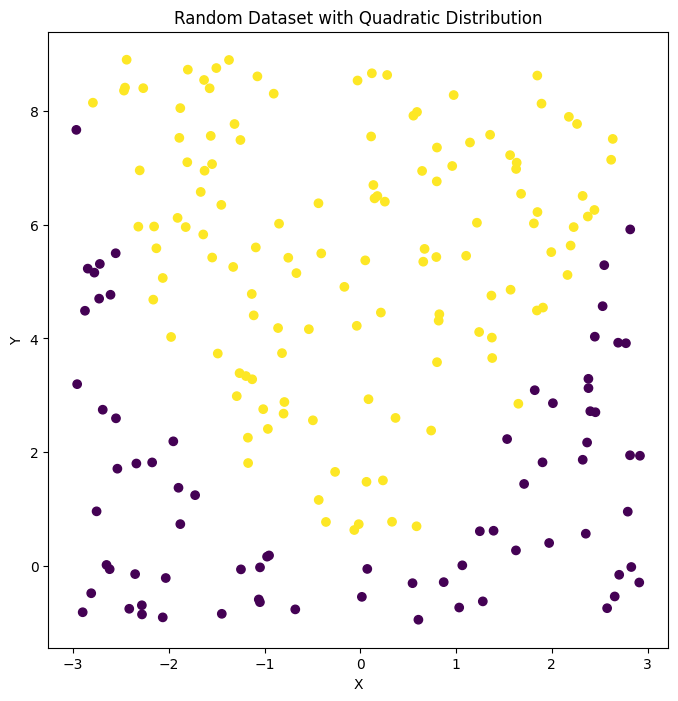

In [ ]:
#visualisation
plt.figure(figsize=(8, 8))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Random Dataset with Quadratic Distribution')

plt.show()

In [ ]:
#seperate target and feature
X = df[['X', 'Y']]
y = df['Class']

In [ ]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#create svm model
model = SVC(
    kernel='poly',
    degree=2,
    random_state=42
)

In [ ]:
#train the svm
model.fit(X_train, y_train)

SVC(degree=2, kernel='poly', random_state=42)

In [ ]:
#prediction
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 1 0 0
 1 1 0]

Predicted values:
[0 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 1 1 1
 1 1 0]


In [ ]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy Score: 0.9
Accuracy Percentage: 90.0 %


In [ ]:
#classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.92      0.92      0.92        25

    accuracy                           0.90        40
   macro avg       0.89      0.89      0.89        40
weighted avg       0.90      0.90      0.90        40



Confusion Matrix:
[[13  2]
 [ 2 23]]


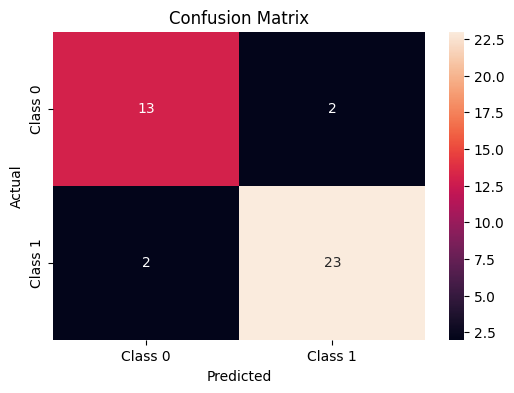

In [ ]:
#confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sn.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

### Summary of Work

**What we did:**
We built and evaluated a Support Vector Machine (SVM) classifier to separate data points classified by a quadratic boundary ($y = x^2$).

**How we did it:**
1. **Data Generation:** Generated 200 random points with 2D coordinates $(X, Y)$ and labeled them based on whether they fall above or below the parabola $y = x^2$.
2. **Visualization:** Plotted the generated points to inspect the quadratic distribution and class separation.
3. **Preprocessing:** Split the dataset into 80% training and 20% testing sets using stratified sampling.
4. **Modeling:** Trained a Support Vector Classifier (SVC) using a **polynomial kernel of degree 2** (matching the quadratic nature of our boundary).
5. **Evaluation:** Tested the model's performance, achieving **90% accuracy**, and visualized the results using a classification report and a confusion matrix.